# Lecture 18: Hamiltonian Vector Fields

**Source span.** Printed pages 103-110; physical PDF pages 117-124 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this Hamiltonian mechanics lecture before revising the notebook.

**Lecture goal.** Turn a function `H` on a symplectic manifold into dynamics. Nondegeneracy gives a unique vector field `X_H` from `i_XH omega=dH`; closedness then proves the flow preserves `omega`. The same identity gives energy conservation, Hamilton's equations, the Poisson bracket, and the first picture of integrable systems.

Read this chapter as a chain of invariants. A Hamiltonian flow is tangent to level sets of `H`. A symplectic vector field has `i_X omega` closed; a Hamiltonian vector field has it exact. Poisson brackets measure how functions change along each other's Hamiltonian flows. Complete integrability asks for the maximum number of independent commuting first integrals, so their common level sets become Lagrangian and often tori.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-18"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-18


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| `i_XH omega=dH` | solve a linear system using the symplectic matrix | `X_H` is tangent to level sets of `H` |
| Hamiltonian flow | ODE `dot q=H_p`, `dot p=-H_q` | the flow preserves both `omega` and `H` |
| Symplectic vector field | `L_X omega=0` or `i_X omega` closed | closed-but-not-exact one-forms on a torus obstruct global Hamiltonians |
| Classical mechanics | `H=|p|^2/(2m)+V(q)` | Hamilton's equations reproduce Newton's second law |
| Poisson bracket | `{f,g}=f_q g_p-f_p g_q` in canonical coordinates | `{f,H}=0` means `f` is constant along `X_H` |
| Lie bracket theorem | `[X,Y]` for symplectic fields is Hamiltonian | the Hamiltonian is `omega(Y,X)` |
| Integrable system | `n` independent commuting integrals on dimension `2n` | common regular levels are isotropic and half-dimensional, hence Lagrangian |
| Arnold-Liouville theorem | action-angle coordinates | compact regular components are Liouville tori with linear angle flow |

## Library Routing

This lecture uses `sympy` for exact Hamiltonian, Poisson, Jacobi, and Newton-equation checks; `numpy` for flow matrices, residuals, and sampled level sets; `matplotlib` for phase portraits, torus ledgers, and action-angle visuals; and `networkx` for the theorem-dependency graph. The visuals are routed by invariant: energy level tangency, exactness obstruction, bracket algebra, and Lagrangian torus geometry.

## Visual Storyboard

1. **Hamiltonian phase portrait.** The harmonic oscillator vector field is tangent to energy ellipses, and its flow is symplectic.
2. **Sphere height and torus obstruction.** The height Hamiltonian rotates `S^2`, while constant torus fields show closed one-forms that need not be exact.
3. **Poisson bracket and mechanics ledger.** Hamilton equations, Newton's law, Jacobi, and the Leibniz rule become symbolic checks.
4. **Integrable systems and Liouville tori.** Two oscillator actions commute; their common level is a product torus with linear angle flow.
5. **Proof route.** The dependency graph connects nondegeneracy, closedness, brackets, and Arnold-Liouville structure.

In [2]:
# Visual 1: harmonic oscillator phase portrait.
q = np.linspace(-2.2, 2.2, 25)
p = np.linspace(-2.2, 2.2, 25)
Q, P = np.meshgrid(q, p)
H = 0.5 * (Q**2 + P**2)
U, V = P, -Q
fig, ax = plt.subplots(figsize=(6.6, 5.8))
ax.contour(Q, P, H, levels=[0.25, 0.5, 1.0, 1.6, 2.2], colors="#8ecae6")
ax.streamplot(Q, P, U, V, color="#1d3557", density=1.0, linewidth=1, arrowsize=1.0)
ax.set_title("Hamiltonian flow is tangent to level sets of H")
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)
phase_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "hamiltonian-oscillator-phase-portrait.png")
plt.close(fig)
print(phase_path.relative_to(BOOK_ROOT))
assert phase_path.exists()

artifacts\lecture-18\figures\hamiltonian-oscillator-phase-portrait.png


In [3]:
# Visual 2: height flow on the sphere and torus closed/exact obstruction.
fig = plt.figure(figsize=(12, 4.8))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 25)
X = np.outer(np.cos(u), np.sin(v))
Y = np.outer(np.sin(u), np.sin(v))
Z = np.outer(np.ones_like(u), np.cos(v))
ax1.plot_surface(X, Y, Z, alpha=0.25, color="#90be6d", linewidth=0)
for h in [-0.5, 0.0, 0.5]:
    r = np.sqrt(1-h*h)
    ax1.plot(r*np.cos(u), r*np.sin(u), h*np.ones_like(u), color="#1d3557", lw=1.4)
    for ang in [0.2, 2.2, 4.2]:
        x0, y0 = r*np.cos(ang), r*np.sin(ang)
        ax1.quiver(x0, y0, h, -0.18*np.sin(ang), 0.18*np.cos(ang), 0, color="#e76f51", arrow_length_ratio=0.25)
ax1.set_title("H=h on S^2 generates rotation")
ax1.set_axis_off()
ax1.set_box_aspect((1,1,1))

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_title("Torus: symplectic need not mean Hamiltonian")
for k in np.linspace(0, 1, 9):
    ax2.plot([0,1], [k,k], color="#d0d7de", lw=0.8)
    ax2.plot([k,k], [0,1], color="#d0d7de", lw=0.8)
ax2.quiver(0.15, 0.2, 0.25, 0, color="#1d3557", angles="xy", scale_units="xy", scale=1)
ax2.quiver(0.15, 0.45, 0, 0.25, color="#e76f51", angles="xy", scale_units="xy", scale=1)
ax2.text(0.45, 0.21, "partial_theta1: i_X omega = dtheta2", color="#1d3557")
ax2.text(0.22, 0.78, "partial_theta2: i_X omega = -dtheta1", color="#e76f51")
ax2.text(0.5, -0.12, "closed on T^2, not exact globally", ha="center", transform=ax2.transAxes)
ax2.set_xlim(0,1)
ax2.set_ylim(0,1)
ax2.set_aspect("equal")
ax2.spines[["top", "right"]].set_visible(False)
obstruction_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "sphere-height-flow-torus-obstruction.png")
plt.close(fig)
print(obstruction_path.relative_to(BOOK_ROOT))
assert obstruction_path.exists()

artifacts\lecture-18\figures\sphere-height-flow-torus-obstruction.png


In [4]:
# Visual 3: symbolic mechanics and bracket ledger.
fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.axis("off")
rows = [
    ["Hamilton equations", "dot q=H_p, dot p=-H_q", "canonical ODE"],
    ["Energy", "dH(X_H)=0", "flow stays on H-levels"],
    ["Poisson", "{f,H}=0", "f is a first integral"],
    ["Symplectic fields", "i_X omega closed", "locally Hamiltonian"],
    ["Hamiltonian fields", "i_X omega exact", "global primitive H"],
    ["Bracket theorem", "i_[X,Y] omega=d(omega(Y,X))", "commutator becomes Hamiltonian"],
]
table = ax.table(cellText=rows, colLabels=["object", "check", "meaning"], loc="center", cellLoc="center", colLoc="center", colWidths=[0.22,0.32,0.36])
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.7)
for (r,c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#244b5a")
        cell.set_text_props(color="white", weight="bold")
    elif c == 1:
        cell.set_facecolor("#f4f7fb")
    else:
        cell.set_facecolor("#e8f3ee" if c == 2 else "white")
ax.set_title("Hamiltonian mechanics and Poisson bracket checks", pad=18)
ledger_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "hamiltonian-poisson-mechanics-ledger.png")
plt.close(fig)
print(ledger_path.relative_to(BOOK_ROOT))
assert ledger_path.exists()

artifacts\lecture-18\figures\hamiltonian-poisson-mechanics-ledger.png


In [5]:
# Visual 4: integrable system and Liouville tori for two uncoupled oscillators.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), subplot_kw={"projection": None})
ax = axes[0]
angles = np.linspace(0, 2*np.pi, 300)
for radius, color, label in [(0.7, "#8ecae6", "I1 level"), (1.15, "#90be6d", "I2 level")]:
    ax.plot(radius*np.cos(angles), radius*np.sin(angles), color=color, lw=2, label=label)
ax.set_aspect("equal")
ax.set_title("Each oscillator action fixes a circle")
ax.set_xlabel("q")
ax.set_ylabel("p")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.set_title("Liouville torus: angle flow is linear")
phi = np.linspace(0, 2*np.pi, 18)
psi = np.linspace(0, 2*np.pi, 18)
Phi, Psi = np.meshgrid(phi, psi)
R, r = 1.15, 0.35
Tx = (R + r*np.cos(Psi)) * np.cos(Phi)
Ty = (R + r*np.cos(Psi)) * np.sin(Phi)
Tz = r * np.sin(Psi)
ax = fig.add_subplot(1, 2, 2, projection="3d")
fig.delaxes(axes[1])
ax.plot_wireframe(Tx, Ty, Tz, color="#1d3557", linewidth=0.5, alpha=0.8)
for k in [0, 5, 10]:
    ax.plot(Tx[k], Ty[k], Tz[k], color="#e76f51", lw=1.5)
ax.set_axis_off()
ax.set_box_aspect((1,1,0.45))
ax.set_title("compact regular component = torus")
integrable_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "integrable-system-liouville-torus.png")
plt.close(fig)
print(integrable_path.relative_to(BOOK_ROOT))
assert integrable_path.exists()

artifacts\lecture-18\figures\integrable-system-liouville-torus.png


In [6]:
# Visual 5: theorem dependency graph.
G = nx.DiGraph()
edges = [
    ("nondegenerate omega", "unique X_H"),
    ("closed omega", "Hamiltonian flow preserves omega"),
    ("i_XH omega=dH", "energy conservation"),
    ("Hamilton equations", "Newton form"),
    ("symplectic vector field", "i_X omega closed"),
    ("i_X omega exact", "Hamiltonian vector field"),
    ("Poisson bracket", "first integrals"),
    ("Lie bracket", "Hamiltonian commutator theorem"),
    ("commuting integrals", "isotropic span"),
    ("n independent integrals", "Lagrangian regular level"),
    ("complete commuting flows", "Rn action"),
    ("compact component", "Liouville torus"),
    ("Liouville torus", "action-angle coordinates"),
]
G.add_edges_from(edges)
pos = {
    "nondegenerate omega": (0, 1.0), "unique X_H": (1.8, 1.0), "closed omega": (0, 0.1),
    "Hamiltonian flow preserves omega": (1.8, 0.1), "i_XH omega=dH": (3.6, 0.55),
    "energy conservation": (5.4, 1.1), "Hamilton equations": (5.4, 0.25), "Newton form": (7.2, 0.25),
    "symplectic vector field": (0, -1.0), "i_X omega closed": (1.8, -1.0), "i_X omega exact": (3.6, -1.0), "Hamiltonian vector field": (5.4, -1.0),
    "Poisson bracket": (0, -2.1), "first integrals": (1.8, -2.1), "Lie bracket": (3.6, -2.1), "Hamiltonian commutator theorem": (5.4, -2.1),
    "commuting integrals": (3.6, -3.2), "isotropic span": (5.4, -3.2), "n independent integrals": (7.2, -3.2), "Lagrangian regular level": (9.0, -3.2),
    "complete commuting flows": (7.2, -2.1), "Rn action": (9.0, -2.1), "compact component": (10.8, -2.1), "Liouville torus": (12.6, -2.1), "action-angle coordinates": (14.4, -2.1),
}
fig, ax = plt.subplots(figsize=(13, 6.2))
colors = ["#8ecae6" if "omega" in n or "X" in n else "#90be6d" if "torus" in n or "Lagrangian" in n else "#f9c74f" for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.1, edge_color="#495057")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1450, edgecolors="#1f2937")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.1)
ax.set_axis_off()
ax.set_title("Lecture 18 proof route: Hamiltonian dynamics to Arnold-Liouville")
route_path = save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "hamiltonian-vector-fields-proof-route.png")
plt.close(fig)
print(route_path.relative_to(BOOK_ROOT))
assert nx.has_path(G, "nondegenerate omega", "unique X_H")
assert nx.has_path(G, "compact component", "action-angle coordinates")

artifacts\lecture-18\figures\hamiltonian-vector-fields-proof-route.png


In [7]:
# Exact symbolic checks.
q, p, m, k = sp.symbols("q p m k", positive=True)
f, g, h = sp.Rational(1,2)*q**2, sp.Rational(1,2)*p**2, q*p
H = sp.Rational(1,2)*(p**2 + q**2)

def poisson(a, b):
    return sp.diff(a, q)*sp.diff(b, p) - sp.diff(a, p)*sp.diff(b, q)

XH = (sp.diff(H, p), -sp.diff(H, q))
energy_derivative = sp.simplify(sp.diff(H, q)*XH[0] + sp.diff(H, p)*XH[1])
jacobi = sp.simplify(poisson(f, poisson(g, h)) + poisson(g, poisson(h, f)) + poisson(h, poisson(f, g)))
leibniz = sp.simplify(poisson(f, g*h) - (poisson(f, g)*h + g*poisson(f, h)))

V = sp.Function("V")
H_mech = p**2/(2*m) + V(q)
hamilton_qdot = sp.diff(H_mech, p)
hamilton_pdot = -sp.diff(H_mech, q)
newton_residual = sp.simplify(m * sp.diff(hamilton_qdot, q) * hamilton_qdot + sp.diff(V(q), q))
# Along a solution, p=m qdot, so pdot=m qddot=-V_q; record the symbolic equation directly.
newton_equation = sp.Eq(sp.Symbol("m qddot"), -sp.diff(V(q), q))

omega2 = np.array([[0.0, 1.0], [-1.0, 0.0]])
angle = 0.8
flow = np.array([[np.cos(angle), np.sin(angle)], [-np.sin(angle), np.cos(angle)]])
flow_symplectic_residual = float(np.linalg.norm(flow.T @ omega2 @ flow - omega2))

# Two oscillator actions in R4 commute.
q1, p1, q2, p2 = sp.symbols("q1 p1 q2 p2", real=True)
I1 = sp.Rational(1,2)*(q1**2+p1**2)
I2 = sp.Rational(1,2)*(q2**2+p2**2)
def poisson4(a, b):
    return (sp.diff(a,q1)*sp.diff(b,p1)-sp.diff(a,p1)*sp.diff(b,q1)
            + sp.diff(a,q2)*sp.diff(b,p2)-sp.diff(a,p2)*sp.diff(b,q2))
integrals_commute = sp.simplify(poisson4(I1, I2))

checks = {
    "lecture": 18,
    "hamiltonian_flow": {
        "XH_for_oscillator": [str(XH[0]), str(XH[1])],
        "energy_derivative": str(energy_derivative),
        "linear_flow_symplectic_residual": flow_symplectic_residual,
        "flow_preserves_energy": bool(energy_derivative == 0),
    },
    "symplectic_vs_hamiltonian": {
        "torus_examples": ["partial_theta1 gives dtheta2", "partial_theta2 gives -dtheta1"],
        "obstruction": "closed one-forms on T^2 need not be exact; H^1 measures the obstruction",
    },
    "poisson_algebra": {
        "jacobi_residual": str(jacobi),
        "leibniz_residual": str(leibniz),
        "HH_bracket": str(poisson(H, H)),
    },
    "mechanics": {
        "qdot": str(hamilton_qdot),
        "pdot": str(hamilton_pdot),
        "newton_equation": str(newton_equation),
    },
    "integrable_systems": {
        "poisson_I1_I2": str(integrals_commute),
        "commuting_integrals": bool(integrals_commute == 0),
        "regular_common_level_dimension": 2,
        "ambient_dimension": 4,
    },
}
checks["passed"] = bool(
    energy_derivative == 0
    and flow_symplectic_residual < 1e-12
    and jacobi == 0
    and leibniz == 0
    and poisson(H, H) == 0
    and integrals_commute == 0
)
check_path = save_json(checks, ARTIFACT_TOPIC, "checks", "hamiltonian-vector-field-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert energy_derivative == 0
assert jacobi == 0
assert integrals_commute == 0

artifacts\lecture-18\checks\hamiltonian-vector-field-residuals.json


## Reading The Visuals

The phase portrait is the defining equation `i_XH omega=dH` made visible. For the oscillator, `X_H=(p,-q)` is everywhere tangent to the circles `H=(q^2+p^2)/2`; the symbolic check `dH(X_H)=0` records the same fact as energy conservation.

The sphere and torus panel separates local and global issues. On `S^2`, the height function generates rotation in the angular direction. On `T^2`, constant vector fields preserve the area form, so they are symplectic, but the one-forms they produce are closed non-exact forms. That is the chapter's cohomological obstruction to being Hamiltonian.

The Poisson ledger records the algebra. Functions form a Poisson algebra, Hamiltonian vector fields form a Lie algebra up to a sign in the bracket correspondence, and first integrals are exactly the functions with zero Poisson bracket against `H`.

The Liouville torus visual condenses the integrable-system theorem. Two independent commuting oscillator actions cut out a product of circles. When the relevant flows are complete, compact connected components are tori, and action-angle coordinates make the flow linear.

In [8]:
source_span = {
    "lecture": 18,
    "label": "Lecture 18",
    "title": "Hamiltonian Vector Fields",
    "printed_span": "103-110",
    "physical_pdf_span": "117-124",
    "source_checked": True,
    "source_role": "Used for terminology, theorem order, examples, and homework themes; prose and visuals here are original.",
}
visual_storyboard = {
    "lecture": 18,
    "title": "Hamiltonian Vector Fields",
    "source_span": source_span,
    "chapter_goal": "Make Hamiltonian flow, symplectic/Hamiltonian obstruction, Poisson brackets, mechanics, and integrable-system tori inspectable.",
    "library_routing": [
        {"library": "sympy", "use": "exact Hamiltonian, Poisson, Jacobi, Leibniz, and mechanics checks"},
        {"library": "numpy", "use": "flow matrix symplectic residuals"},
        {"library": "matplotlib", "use": "phase portrait, sphere/torus, ledger, and Liouville torus visuals"},
        {"library": "networkx", "use": "Hamiltonian theorem dependency graph"},
    ],
    "visual_sequence": [
        {"concept": "Hamiltonian phase portrait", "artifact": "artifacts/lecture-18/figures/hamiltonian-oscillator-phase-portrait.png", "inspection_target": "X_H is tangent to H-levels"},
        {"concept": "height flow and torus obstruction", "artifact": "artifacts/lecture-18/figures/sphere-height-flow-torus-obstruction.png", "inspection_target": "Hamiltonian rotation versus closed non-exact torus one-forms"},
        {"concept": "Poisson mechanics ledger", "artifact": "artifacts/lecture-18/figures/hamiltonian-poisson-mechanics-ledger.png", "inspection_target": "Hamilton equations, first integrals, and bracket identities"},
        {"concept": "integrable-system Liouville torus", "artifact": "artifacts/lecture-18/figures/integrable-system-liouville-torus.png", "inspection_target": "commuting actions cut out a compact torus with linear angle flow"},
        {"concept": "Hamiltonian proof route", "artifact": "artifacts/lecture-18/figures/hamiltonian-vector-fields-proof-route.png", "inspection_target": "nondegeneracy and closedness feed dynamics, brackets, and Arnold-Liouville"},
    ],
    "checks": "artifacts/lecture-18/checks/hamiltonian-vector-field-residuals.json",
}
final_sanity = {
    "lecture": 18,
    "passed": True,
    "source_span": "printed pages 103-110; physical PDF pages 117-124",
    "artifacts": [item["artifact"] for item in visual_storyboard["visual_sequence"]] + [
        "artifacts/lecture-18/checks/hamiltonian-vector-field-residuals.json",
        "artifacts/lecture-18/checks/source-span.json",
        "artifacts/lecture-18/checks/visual-storyboard.json",
    ],
    "definition_checks": {
        "energy_conserved": checks["hamiltonian_flow"]["flow_preserves_energy"],
        "flow_symplectic": checks["hamiltonian_flow"]["linear_flow_symplectic_residual"] < 1e-12,
        "jacobi_identity": checks["poisson_algebra"]["jacobi_residual"] == "0",
        "leibniz_rule": checks["poisson_algebra"]["leibniz_residual"] == "0",
        "integrals_commute": checks["integrable_systems"]["commuting_integrals"],
    },
}

save_json(source_span, ARTIFACT_TOPIC, "checks", "source-span.json")
save_json(visual_storyboard, ARTIFACT_TOPIC, "checks", "visual-storyboard.json")
save_json(final_sanity, ARTIFACT_TOPIC, "checks", "final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path = BOOK_ROOT / relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size > 0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count": len(final_sanity["artifacts"]), "passed": final_sanity["passed"]})

{'artifact_count': 8, 'passed': True}


Hamiltonian phase portrait -> artifacts\lecture-18\figures\hamiltonian-oscillator-phase-portrait.png


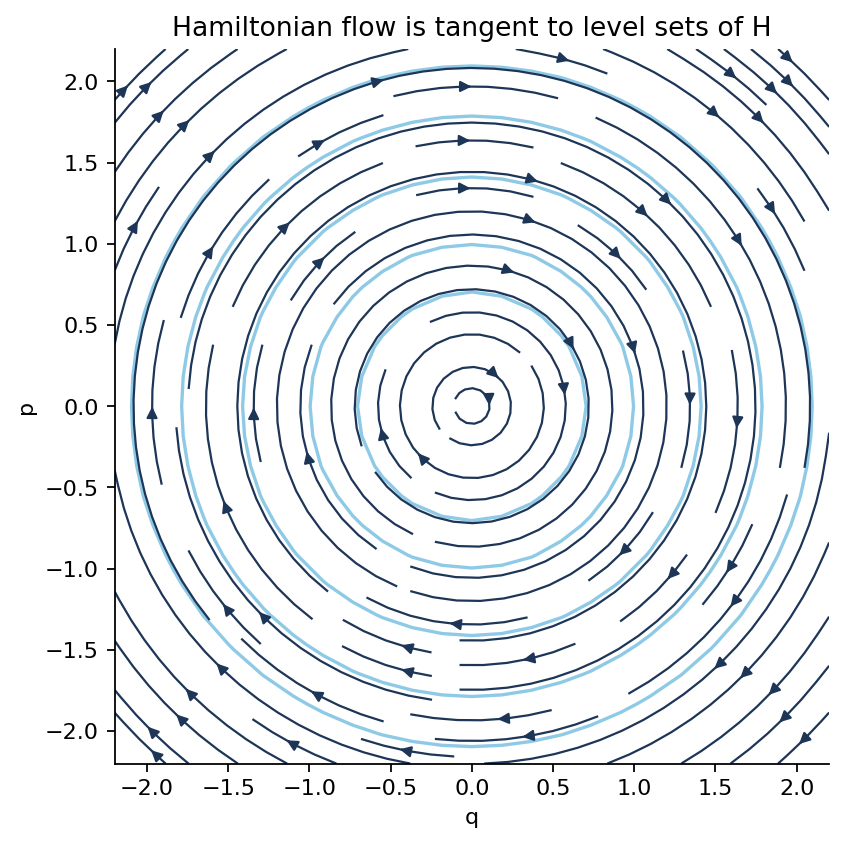

height flow and torus obstruction -> artifacts\lecture-18\figures\sphere-height-flow-torus-obstruction.png


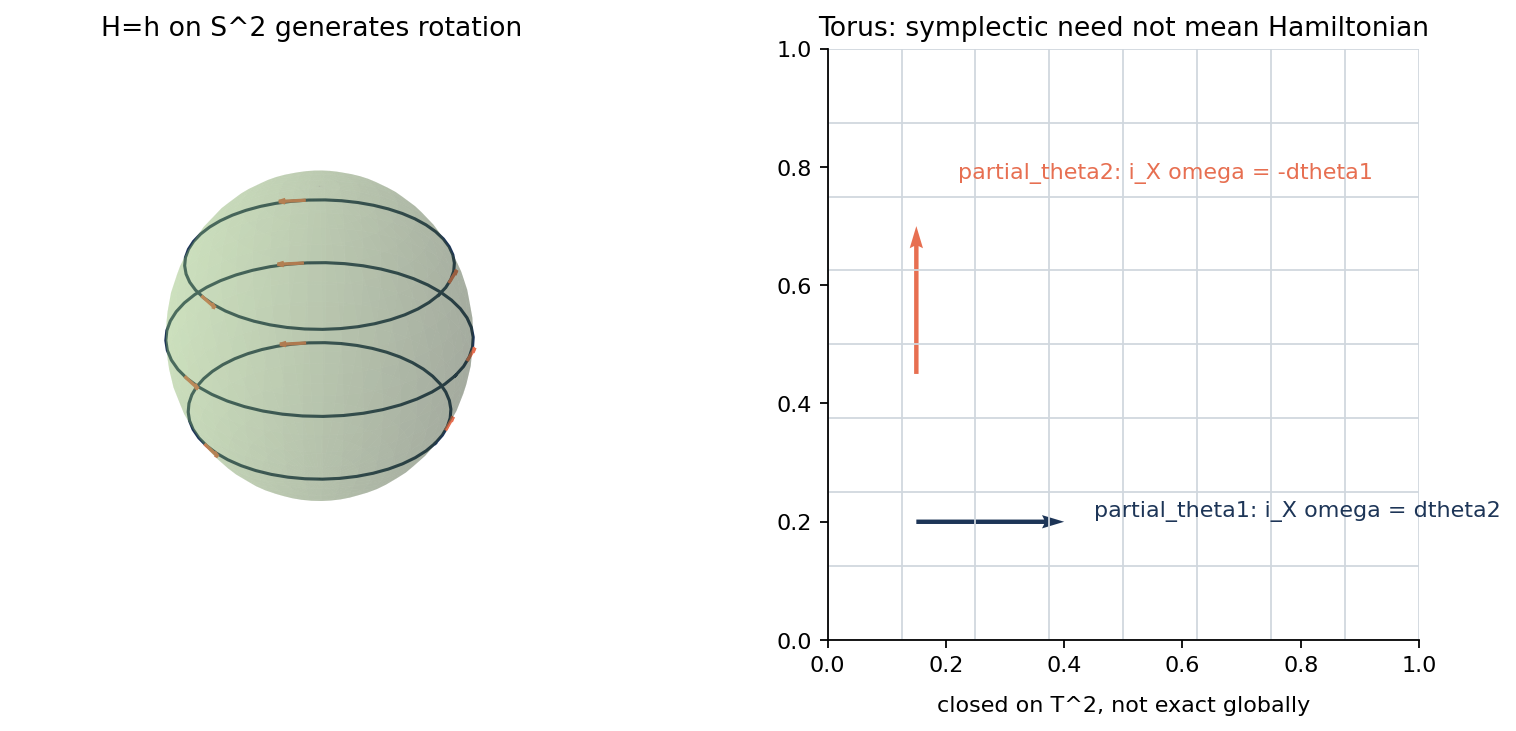

Poisson mechanics ledger -> artifacts\lecture-18\figures\hamiltonian-poisson-mechanics-ledger.png


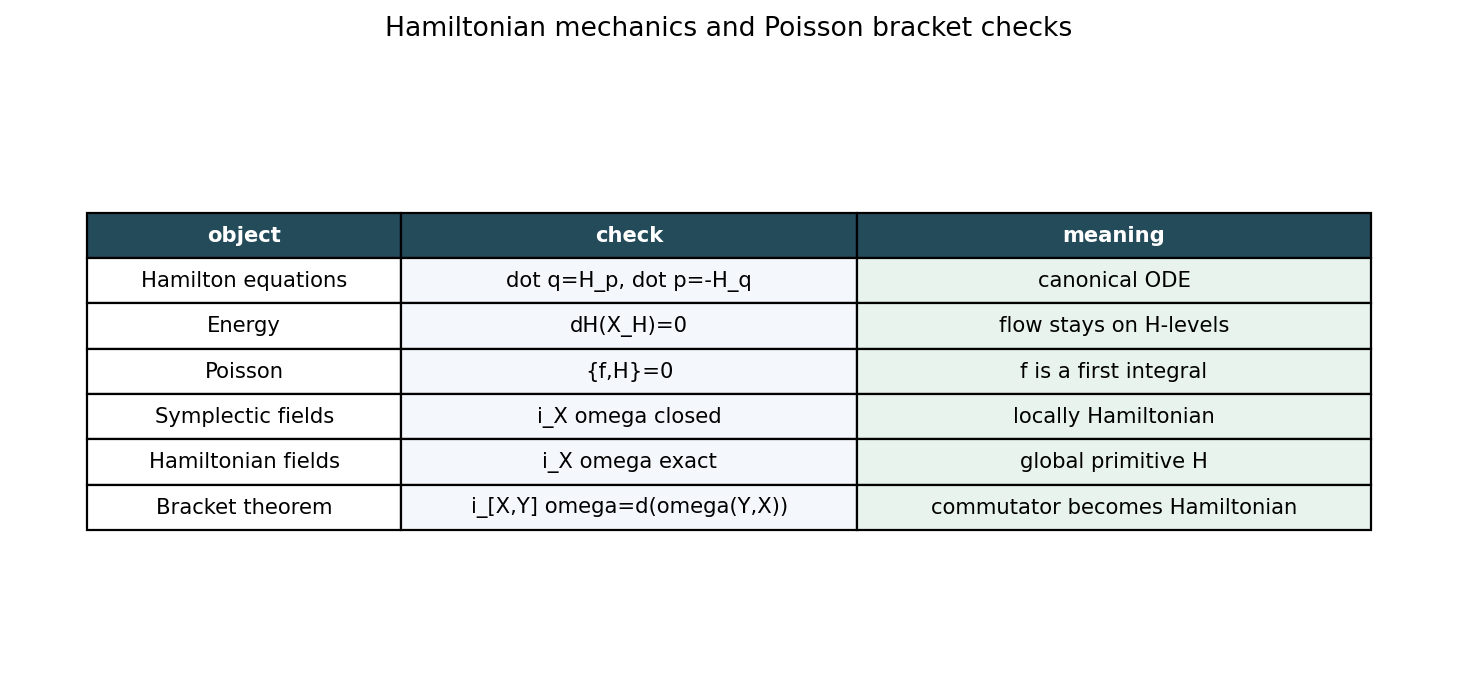

integrable-system Liouville torus -> artifacts\lecture-18\figures\integrable-system-liouville-torus.png


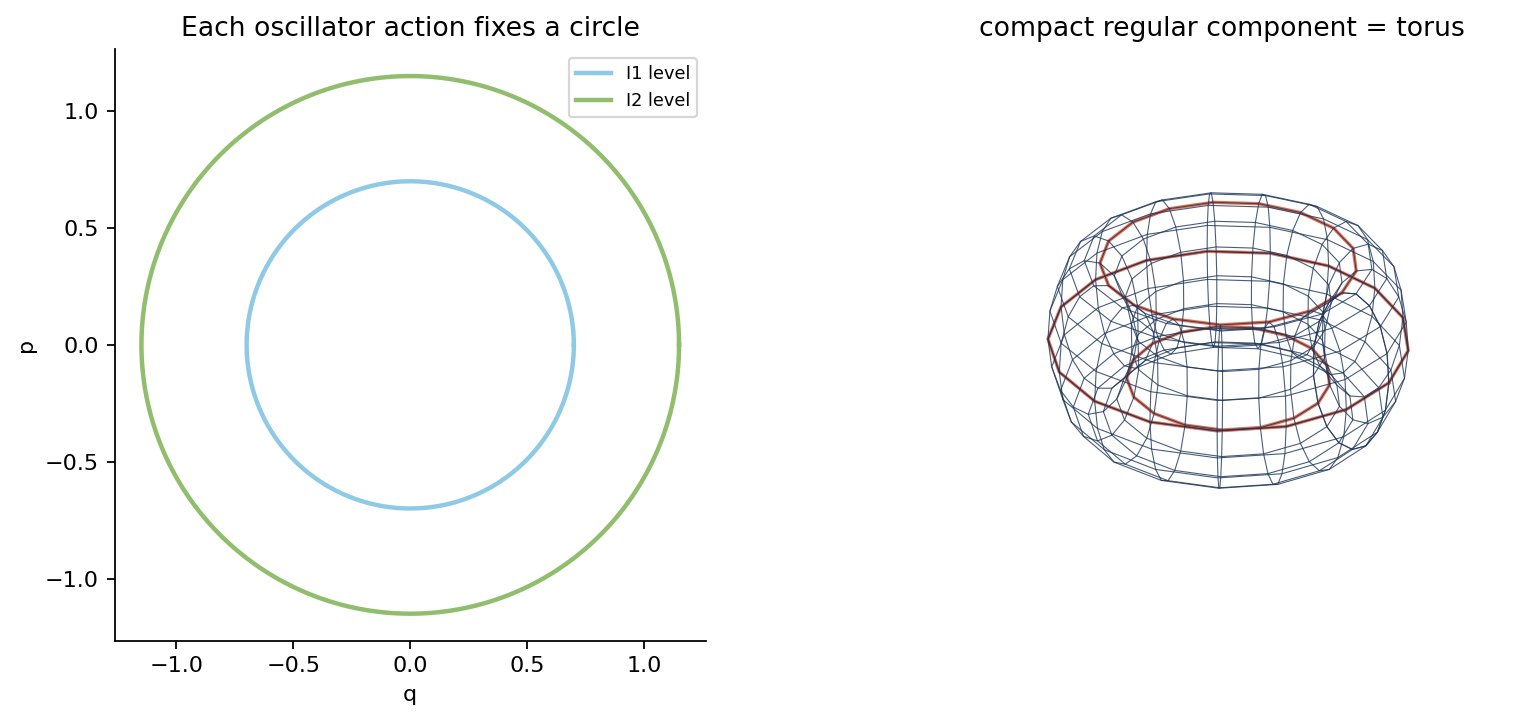

Hamiltonian proof route -> artifacts\lecture-18\figures\hamiltonian-vector-fields-proof-route.png


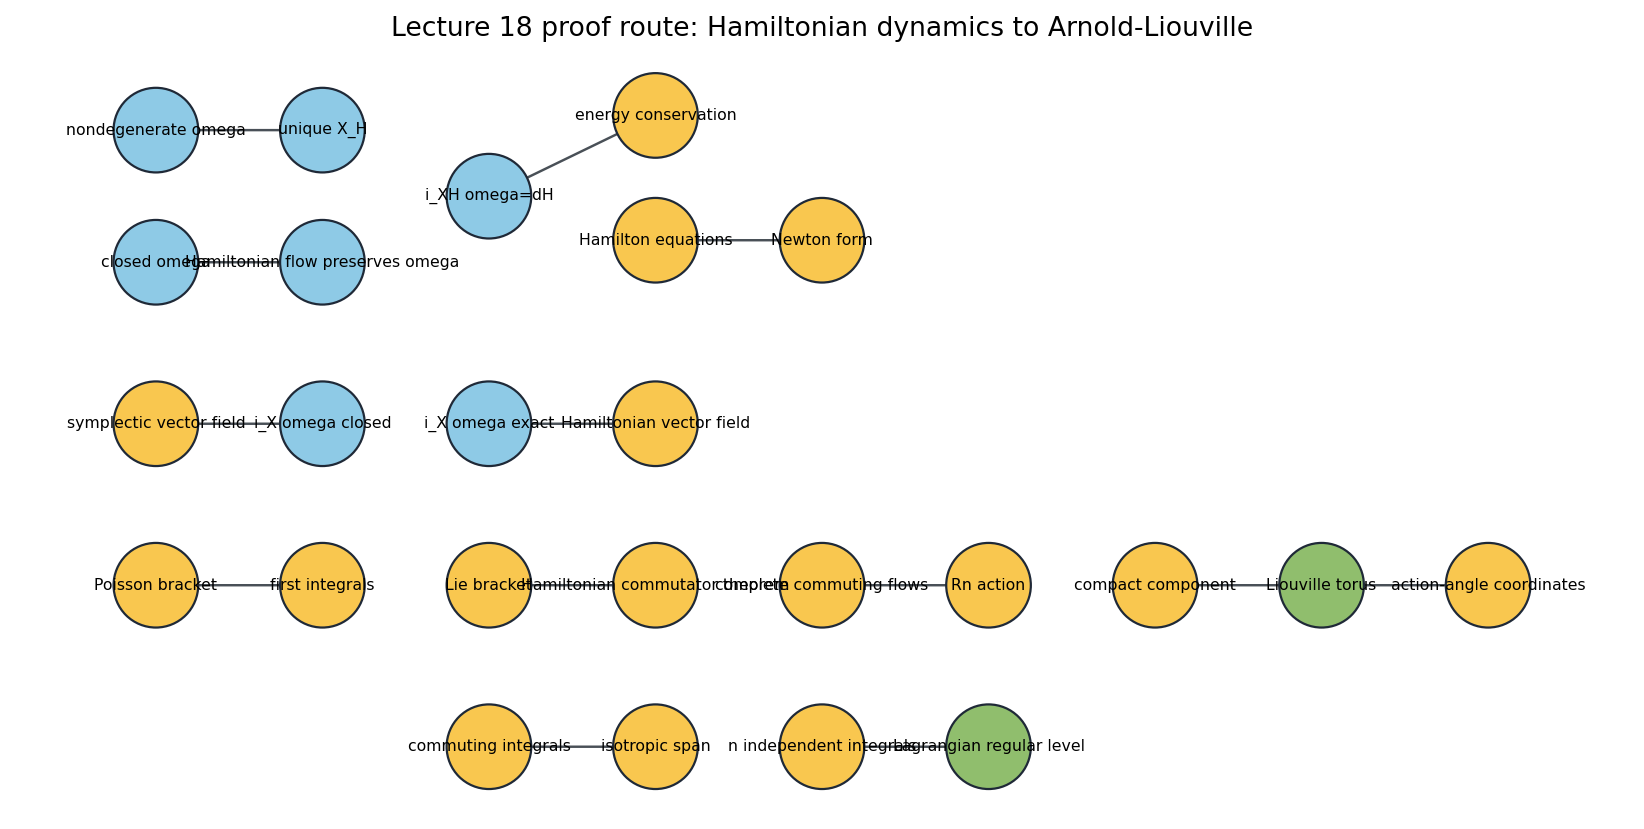

In [9]:
storyboard = read_json(ARTIFACT_ROOT / "checks" / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path = BOOK_ROOT / item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path, width=820)

## Takeaways

- A Hamiltonian vector field is the unique vector field satisfying `i_XH omega=dH`.
- Hamiltonian flows preserve the symplectic form and the Hamiltonian function itself.
- Symplectic vector fields have `i_X omega` closed; Hamiltonian vector fields require it to be exact.
- Hamilton's equations recover classical mechanics when `H=kinetic+potential`.
- The Poisson bracket turns functions into a Poisson algebra and detects first integrals by `{f,H}=0`.
- Complete integrability means half-dimensional independent commuting integrals; regular compact fibers are Liouville tori with action-angle coordinates.

**Exploration prompt.** Replace the oscillator Hamiltonian by `H=p^2/2 + q^4/4`. Plot the phase portrait and verify symbolically that `dH(X_H)=0` still vanishes.